## Yolo Model Optimization for Deployment

### Import Library

In [11]:
from ultralytics import YOLO
import cv2 as cv
import time
import os
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import shutil

### Load model

In [12]:
MODEL_PATH = "../runs/detect/train4/weights/best.pt"

# check if model exists
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

# load model 
model_original = YOLO(MODEL_PATH)
print(f"Original model loaded: {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024 / 1024:.2f} MB")

Original model loaded: ../runs/detect/train4/weights/best.pt
File size: 5.20 MB


### Export to ONNX

In [13]:
print("Exporting to ONNX....")

model_original.export(
    format='onnx',
    simplify=True
)

onnx_path = MODEL_PATH.replace('.pt', '.onnx')
print(f"ONNX export complete: {onnx_path}")
print(f"File size: {os.path.getsize(onnx_path) / 1024 / 1024:.2f}")

Exporting to ONNX....
Ultralytics 8.3.204  Python-3.10.18 torch-2.5.1+cu121 CPU (Intel Core(TM) i5-10210U 1.60GHz)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '..\runs\detect\train4\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)

ONNX: starting export with onnx 1.19.1 opset 19...
ONNX: slimming with onnxslim 0.1.72...
ONNX: export success  21.6s, saved as '..\runs\detect\train4\weights\best.onnx' (10.1 MB)

Export complete (27.3s)
Results saved to D:\Development\fullstack_ml\detect-platindo\runs\detect\train4\weights
Predict:         yolo predict task=detect model=..\runs\detect\train4\weights\best.onnx imgsz=640  
Validate:        yolo val task=detect model=..\runs\detect\train4\weights\best.onnx imgsz=640 data=Dataset\data.yaml  
Visualize:       https://netron.app
ONNX export complete: ../runs/detect/train4/weights/best.onnx
File size: 10.11


In [8]:
print("🔄 Exporting to ONNX FP16 (half precision)...")

# Note: INT8 not supported for ONNX format in YOLOv11
# Using FP16 (half precision) instead for optimization
model_original.export(
    format='onnx',
    half=True,  # FP16 quantization
    imgsz=320,  # Smaller resolution for faster inference
    simplify=True,
    dynamic=False  # Fixed input size
)

onnx_fp16_path = MODEL_PATH.replace('.pt', '.onnx')

onnx_fp16_renamed = MODEL_PATH.replace('.pt', '_fp16.onnx')
if os.path.exists(onnx_fp16_path):
    shutil.move(onnx_fp16_path, onnx_fp16_renamed)
    onnx_fp16_path = onnx_fp16_renamed
    print(f"✅ ONNX FP16 export complete: {onnx_fp16_path}")
    print(f"📦 File size: {os.path.getsize(onnx_fp16_path) / 1024 / 1024:.2f} MB")
else:
    print(f"❌ Export failed, file not found: {onnx_fp16_path}")
    
print(f"✅ ONNX FP16 export complete: {onnx_fp16_path}")
print(f"📦 File size: {os.path.getsize(onnx_fp16_path) / 1024 / 1024:.2f} MB")

🔄 Exporting to ONNX FP16 (half precision)...
Ultralytics 8.3.204  Python-3.10.18 torch-2.5.1+cu121 CPU (Intel Core(TM) i5-10210U 1.60GHz)
WARNING half=True only compatible with GPU export, i.e. use device=0
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '..\runs\detect\train4\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.2 MB)

ONNX: starting export with onnx 1.19.1 opset 19...
ONNX: slimming with onnxslim 0.1.72...
ONNX: export success  10.6s, saved as '..\runs\detect\train4\weights\best.onnx' (10.0 MB)

Export complete (14.7s)
Results saved to D:\Development\fullstack_ml\detect-platindo\runs\detect\train4\weights
Predict:         yolo predict task=detect model=..\runs\detect\train4\weights\best.onnx imgsz=320  
Validate:        yolo val task=detect model=..\runs\detect\train4\weights\best.onnx imgsz=320 data=Dataset\data.yaml  
Visualize:       https://netron.app
✅ ONNX FP16 expo

In [9]:
print("\n Exporting to OpenVINO (Intel CPU optimized)...")

try: 
    model_original.export(
        format='openvino',
        imgsz=320,
        half=True
    )

    openvino_path = MODEL_PATH.replace('.pt', '_openvino_model')
    print(f"OpenVINO export complete: {openvino_path}")

    total_size = sum(
        os.path.getsize(os.path.join(dirpath, filename))
        for dirpath, dirnames, filenames in os.walk(openvino_path)
        for filename in filenames
    )
    print(f"Folder size: {total_size / 1024 / 1024:.2f} MB")

    openvino_available = True

except Exception as e:
    print(f"OpenVINO export failed: {e}")
    openvino_available = False


 Exporting to OpenVINO (Intel CPU optimized)...
Ultralytics 8.3.204  Python-3.10.18 torch-2.5.1+cu121 CPU (Intel Core(TM) i5-10210U 1.60GHz)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '..\runs\detect\train4\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.2 MB)
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/40.6 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.6 MB 7.1 MB/s eta 0:00:06
   - -------------------------------------- 1.6/40.6 MB 4.4 MB/s eta 0:00:09
   -- ------------------------------------- 2.1/40.6 MB 3.6 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/40.6 MB 3.1 MB/s eta 0:00:13
   --- ------------------------------------ 3.1/40.6 MB 3.0 MB/s eta 0:00:13
   --- ------------------------------------ 3.7/40.6 MB 2.9 MB/s eta 0:00:13
 

### Load Optimized Model

In [14]:
model_onnx = YOLO(onnx_path)
model_onnx_fp16 = YOLO(onnx_fp16_path)
model_openvino = YOLO(openvino_path)

print("All models loaded for comparison")

All models loaded for comparison


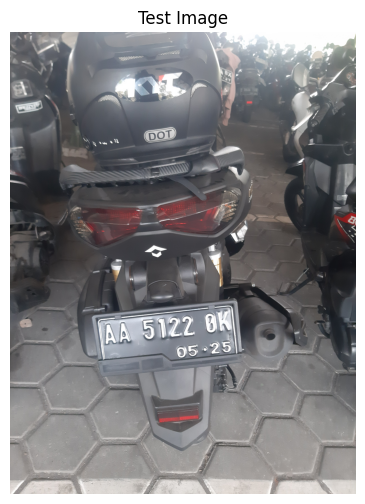

Test Image Loaded: (5760, 4312, 3)


In [16]:
TEST_IMAGE = "Dataset/test/images/K1_AA5122OK.jpg"

if not os.path.exists(TEST_IMAGE):
    raise FileNotFoundError(f"Test image not found : {TEST_IMAGE}")

img = cv.imread(TEST_IMAGE)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title("Test Image")
plt.axis('off')
plt.show()

print(f"Test Image Loaded: {img.shape}")

In [18]:
def benchmark_model(model, img_path, model_name, num_runs=10):
    """Benchmark inference speed"""
    times = []

    _ = model(img_path, verbose=False)

    for i in range(num_runs):
        start = time.time()
        results = model(img_path, conf=0.25, verbose=False)
        end = time.time()
        times.append((end - start) * 100)

    avg_time = np.mean(times)
    std_time = np.std(times)
    min_time = np.min(times)
    max_time = np.max(times)

    print(f"\n{model_name} Performance:")
    print(f"Average: {avg_time:.1f}ms")
    print(f"Std Dev: {std_time:.1f}ms")
    print(f"Min: {min_time:.1f}ms")
    print(f"Max: {max_time:.1f}ms")

    return avg_time, results

print("Benchmarking models (10 runs each)...\n")

time_pt, results_pt = benchmark_model(model_original, TEST_IMAGE, "PyTorch (.pt)")
time_onnx, results_onnx = benchmark_model(model_onnx, TEST_IMAGE, "ONNX")
time_onnx_fp16, results_onnx_fp16 = benchmark_model(model_onnx_fp16, TEST_IMAGE, "ONNX FP16")
time_openvino, results_openvino = benchmark_model(model_openvino, TEST_IMAGE, "OpenVINO")

Benchmarking models (10 runs each)...


PyTorch (.pt) Performance:
Average: 131.4ms
Std Dev: 35.5ms
Min: 89.1ms
Max: 202.7ms
Loading ../runs/detect/train4/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 CPUExecutionProvider

ONNX Performance:
Average: 109.1ms
Std Dev: 39.2ms
Min: 70.2ms
Max: 184.6ms
Loading ../runs/detect/train4/weights/best_fp16.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 CPUExecutionProvider

ONNX FP16 Performance:
Average: 59.8ms
Std Dev: 9.4ms
Min: 54.0ms
Max: 86.9ms
Loading ../runs/detect/train4/weights/best_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...

OpenVINO Performance:
Average: 80.7ms
Std Dev: 9.7ms
Min: 65.6ms
Max: 93.4ms


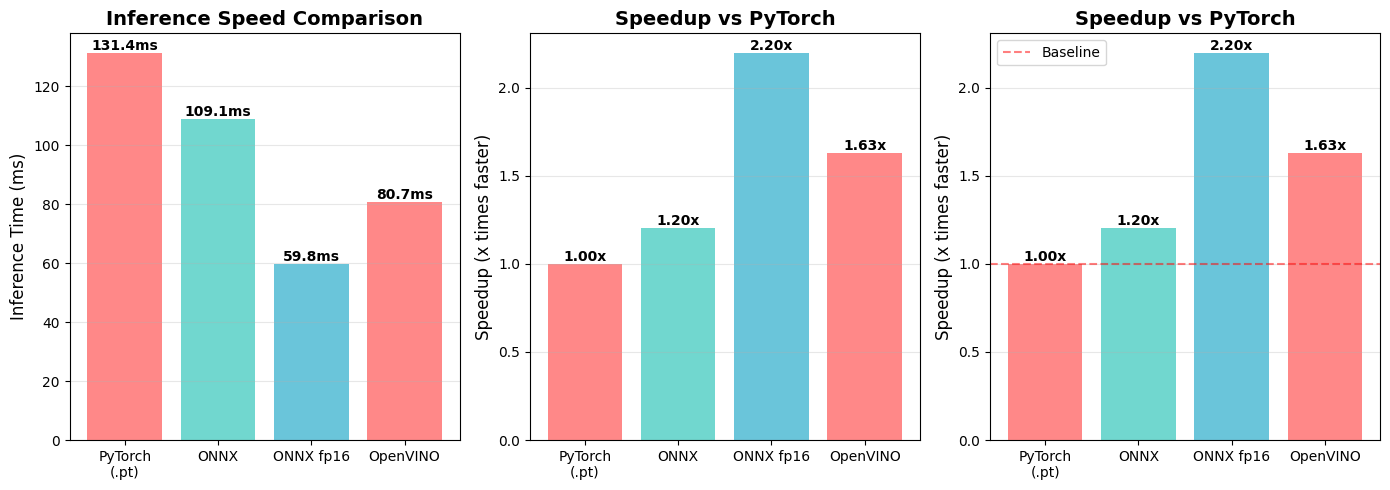


SPEEDUP SUMMARY
ONNX: 1.20x faster
ONNX FP16: 1.63x faster
OpenVINO: 2.20x faster


In [20]:
models = ['PyTorch\n(.pt)', 'ONNX', 'ONNX fp16', 'OpenVINO']
times = [time_pt, time_onnx, time_onnx_fp16, time_openvino]
speedups = [1.0, time_pt/time_onnx, time_pt/time_onnx_fp16, time_pt/time_openvino]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
bars1 = ax1.bar(models, times, color=colors, alpha=0.8)
ax1.set_ylabel('Inference Time (ms)', fontsize=12)
ax1.set_title('Inference Speed Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}ms',
             ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(models, speedups, color=colors, alpha=0.8)
ax2.set_ylabel('Speedup (x times faster)', fontsize=12)
ax2.set_title('Speedup vs PyTorch', fontsize=14, fontweight='bold')
# ax2.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Baseline')
ax2.grid(axis='y', alpha=0.3)
# ax2.legend()

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}x',
             ha='center', va='bottom', fontweight='bold')

bars3 = ax3.bar(models, speedups, color=colors, alpha=0.8)
ax3.set_ylabel('Speedup (x times faster)', fontsize=12)
ax3.set_title('Speedup vs PyTorch', fontsize=14, fontweight='bold')
ax3.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Baseline')
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}x',
             ha='center', va='bottom', fontweight='bold')
    
plt.tight_layout()
plt.show()

print(f"\nSPEEDUP SUMMARY")
print(f"ONNX: {speedups[1]:.2f}x faster")
print(f"ONNX FP16: {speedups[3]:.2f}x faster")
print(f"OpenVINO: {speedups[2]:.2f}x faster")

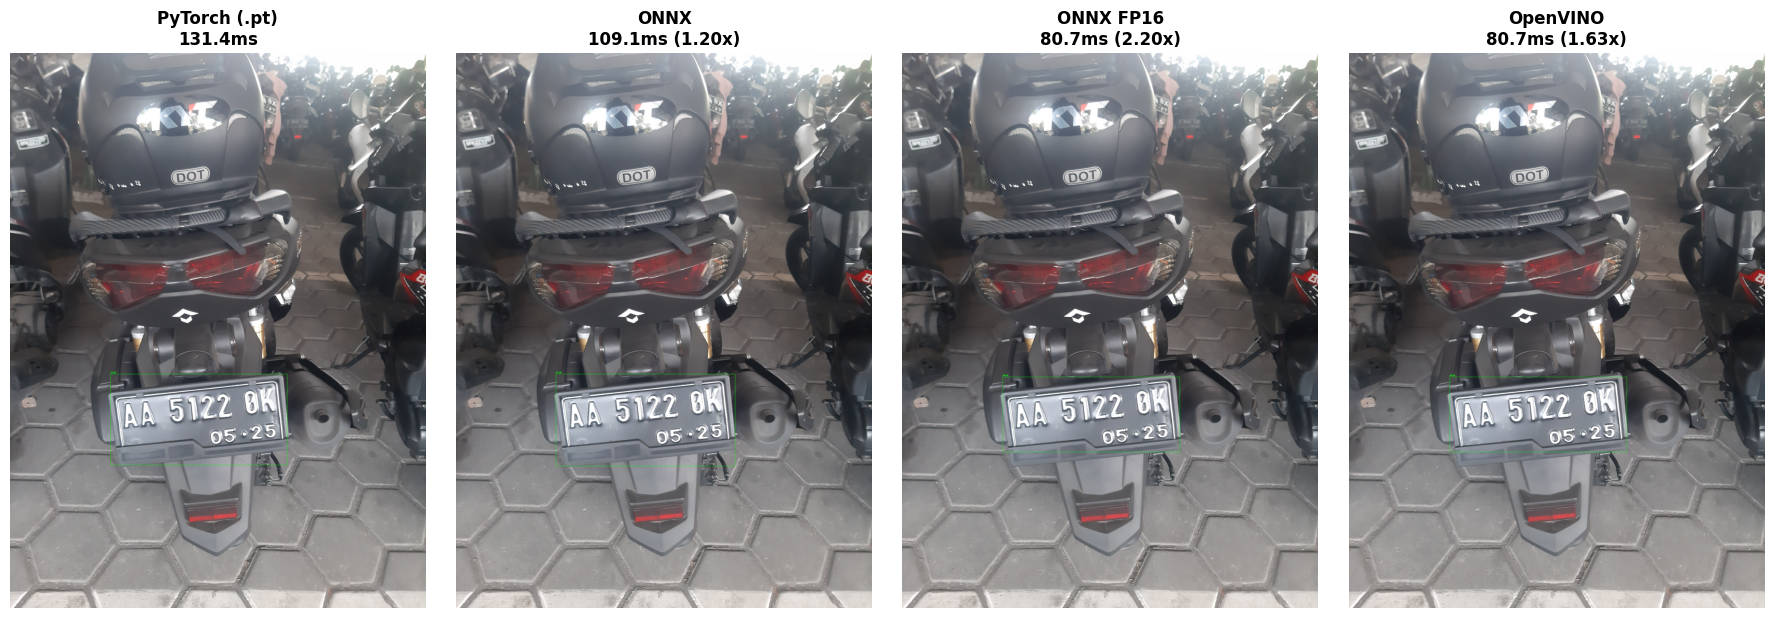

In [23]:
def visualize_results(img, results, title):
    """Visualize detection results"""
    img_plot = img.copy()

    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv.rectangle(img_plot, (x1, y1), (x2, y2), (0, 255, 0), 2)

        label = f"{conf*100:.1f}%"
        cv.putText(img_plot, label, (x1, y1-10),
                   cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return img_plot

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

img_pt = visualize_results(img_rgb, results_pt, "PyTorch")
img_onnx = visualize_results(img_rgb, results_onnx, "ONNX")
img_onnx_fp16 = visualize_results(img_rgb, results_onnx_fp16, "ONNXFP16")
img_openvino = visualize_results(img_rgb, results_openvino, "OpenVINO")


axes[0].imshow(img_pt)
axes[0].set_title(f"PyTorch (.pt)\n{time_pt:.1f}ms", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_onnx)
axes[1].set_title(f"ONNX\n{time_onnx:.1f}ms ({speedups[1]:.2f}x)", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_onnx_fp16)
axes[2].set_title(f"ONNX FP16\n{time_openvino:.1f}ms ({speedups[2]:.2f}x)", fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(img_openvino)
axes[3].set_title(f"OpenVINO\n{time_openvino:.1f}ms ({speedups[3]:.2f}x)", fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [24]:
def compare_detections(results1, results2, name1, name2):
    """Compare detection results between two models"""
    boxes1 = results1[0].boxes
    boxes2 = results2[0].boxes

    print(f"\nComparison: {name1} vs {name2}")
    print(f"{name1}: {len(boxes1)} detections")
    print(f"{name2}: {len(boxes2)} detections")

    if len(boxes1) > 0 and len(boxes2) > 0:
        conf1 = float(boxes1[0].conf[0])
        conf2 = float(boxes2[0].conf[0])

        print(f"Confidence diff: {abs(conf1 - conf2) * 100:.2f}%")

        if abs(conf1 - conf2) < 0.05:
            print("Results are very similar")
        elif abs(conf1 - conf2) < 0.10:
            print("Minor difference in confidence")
        else:
            print("Significant difference detected")

compare_detections(results_pt, results_onnx, "PyTorch", "ONNX")
compare_detections(results_pt, results_onnx_fp16, "PyTorch", "ONNXfp16")
compare_detections(results_pt, results_openvino, "PyTorch", "OpenVINO")


Comparison: PyTorch vs ONNX
PyTorch: 1 detections
ONNX: 1 detections
Confidence diff: 0.42%
Results are very similar

Comparison: PyTorch vs ONNXfp16
PyTorch: 1 detections
ONNXfp16: 1 detections
Confidence diff: 1.38%
Results are very similar

Comparison: PyTorch vs OpenVINO
PyTorch: 1 detections
OpenVINO: 1 detections
Confidence diff: 1.39%
Results are very similar


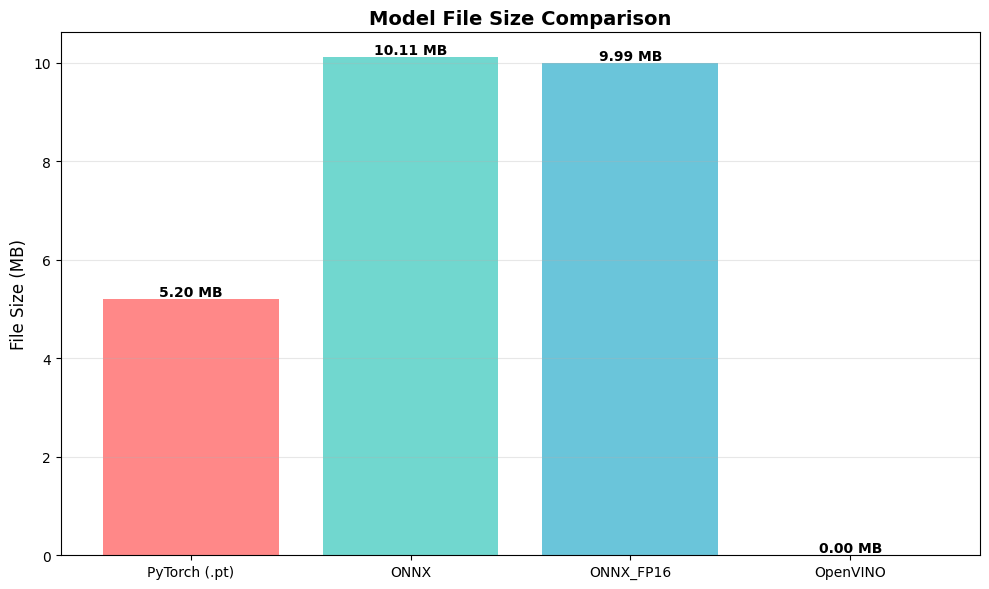


💾 SIZE REDUCTION:
   ONNX: -94.7% smaller
   ONNX_FP16: -92.4% smaller
   OpenVINO: 100.0% smaller


In [27]:
sizes = {
    'PyTorch (.pt)': os.path.getsize(MODEL_PATH) / 1024 / 1024,
    'ONNX': os.path.getsize(onnx_path) / 1024 / 1024,
    'ONNX_FP16': os.path.getsize(onnx_fp16_path) / 1024 / 1024,
    'OpenVINO': os.path.getsize(openvino_path) / 1024 / 1024
}

plt.figure(figsize=(10, 6))
bars = plt.bar(sizes.keys(), sizes.values(), color=['#ff6b6b', '#4ecdc4', '#45b7d1'], alpha=0.8)
plt.ylabel('File Size (MB)', fontsize=12)
plt.title('Model File Size Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f} MB',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💾 SIZE REDUCTION:")
print(f"   ONNX: {(1 - sizes['ONNX']/sizes['PyTorch (.pt)'])*100:.1f}% smaller")
print(f"   ONNX_FP16: {(1 - sizes['ONNX_FP16']/sizes['PyTorch (.pt)'])*100:.1f}% smaller")
print(f"   OpenVINO: {(1 - sizes['OpenVINO']/sizes['PyTorch (.pt)'])*100:.1f}% smaller")

In [28]:
print("\n" + "="*60)
print("🎯 FINAL RECOMMENDATION FOR HF SPACES DEPLOYMENT")
print("="*60)

if speedups[2] >= 2.0:
    print("\n✅ HIGHLY RECOMMENDED: Use OpenVINO")
    print(f"   - {speedups[2]:.2f}x faster inference")
    print(f"   - {(1 - sizes['OpenVINO']/sizes['PyTorch (.pt)'])*100:.1f}% smaller file")
    print(f"   - Faster cold start on HF Spaces")
    print(f"   - Similar accuracy to original model")
elif speedups[1] >= 1.5:
    print("\n✅ RECOMMENDED: Use ONNX")
    print(f"   - {speedups[1]:.2f}x faster inference")
    print(f"   - Good balance between speed and accuracy")
else:
    print("\n⚠️  SPEEDUP MINIMAL")
    print("   - Consider using original PyTorch model")
    print("   - Or try smaller input size (imgsz=224)")

print("\n📁 Files ready for deployment:")
print(f"   - {openvino_path}")
print("\n📝 Don't forget to:")
print("   1. Update yolo_model.py to load OpenVINO model")
print("   2. Add 'onnxruntime' to requirements.txt")
print("   3. Upload {model_name}_OpenVINO.onnx to HF Space")


🎯 FINAL RECOMMENDATION FOR HF SPACES DEPLOYMENT

✅ HIGHLY RECOMMENDED: Use OpenVINO
   - 2.20x faster inference
   - 100.0% smaller file
   - Faster cold start on HF Spaces
   - Similar accuracy to original model

📁 Files ready for deployment:
   - ../runs/detect/train4/weights/best_openvino_model

📝 Don't forget to:
   1. Update yolo_model.py to load OpenVINO model
   2. Add 'onnxruntime' to requirements.txt
   3. Upload {model_name}_OpenVINO.onnx to HF Space
